# Exercise 4: Classification with Logistic Regression

```{admonition} Run or download this notebook
:class: how-to-use

This page is fully readable as it is, and the interactive activities work
here in the browser. To **run or change the Python code**, use the portable
version of the notebook:

- **[Open the portable notebook in Colab](https://colab.research.google.com/github/yoavmp/ml-neuro-tutorials/blob/main/book/downloads/chapter_04/exercise_04_portable.ipynb)**
- **[View or download the portable `.ipynb`](https://raw.githubusercontent.com/yoavmp/ml-neuro-tutorials/main/book/downloads/chapter_04/exercise_04_portable.ipynb)**
  for VS Code or Jupyter

The portable notebook keeps every Python analysis cell and swaps the two
embedded activities for links back to this page.
```

## What this notebook covers

This is Exercise 4 of *Machine Learning for Neuroscience*. Exercises 2-3
used ABIDE's rich neuroimaging table to ask a **regression** question:
predicting a participant's age from cortical structure. Autism diagnosis --
ABIDE's own central scientific question -- has not yet been addressed. This
practice builds one **classifier**: predicting autism diagnosis from the
same brain measurements, and evaluating it honestly.

In this notebook you will:

- build and evaluate one binary classifier for autism diagnosis;
- turn a logistic-regression score into a probability, and a probability
  into a class decision;
- read a confusion matrix and compute accuracy;
- read an ROC curve and understand AUC as threshold-independent ranking
  performance;
- see what class imbalance does to accuracy, and what a stratified
  train/test split does -- and does not -- fix about it.

**Prerequisites:** Exercise 2's train/test workflow, `StandardScaler`,
`Pipeline` / `fit` / `predict` in scikit-learn, and honest held-out
evaluation (Exercises 2-3's train/resubstitution/invalid comparison --
this notebook does not repeat that demonstration a third time).


## 1. The ABIDE classification data

ABIDE's own central scientific distinction is **autism diagnosis**.
Exercises 2-3 used this same rich dataset to ask a regression question about
age instead; this notebook returns to ABIDE's original question. The table
itself is unchanged: the same 1004-participant modelling table, one row per
participant, with the same 360 bilateral cortical-thickness (`fsCT`) columns
used throughout Exercises 2-3.


In [1]:
# Data loading. In the published book this cell is collapsed; it is plain,
# runnable Python -- one public CSV pinned to an immutable commit. Nothing
# here is repository-specific. Same data and provenance as Exercises 2-3.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, confusion_matrix, roc_auc_score, roc_curve,
)

PIN = "e4eed3c4daa7f40b0ba931182a8c7e5e691dba6b"
BASE = f"https://raw.githubusercontent.com/neurohackademy/nh2020-curriculum/{PIN}/tu-machine-learning-yarkoni/data"

model_df = pd.read_csv(f"{BASE}/abide2.tsv", sep="\t")
model_df = model_df.loc[:, [c for c in model_df.columns if not str(c).startswith("Unnamed")]]

BRAIN_COLS = [c for c in model_df.columns if c.startswith("fs")]
print(f"modelling table: {model_df.shape[0]} participants x {model_df.shape[1]} columns")


modelling table: 1004 participants x 1446 columns


In [2]:
# group: 1 = autism, 2 = control -- native to this table, no join needed.
# A compact preview plus class counts and a missingness statement.
preview_cols = ["subject", "site", "group", "age", "sex", "fsCT_L_46_ROI"]
display(model_df[preview_cols].head(3))

class_counts = model_df["group"].value_counts().sort_index()
n_autism = int(class_counts.get(1.0, 0))
n_control = int(class_counts.get(2.0, 0))
n_missing_group = int(model_df["group"].isna().sum())
n_dup_subjects = int(model_df["subject"].duplicated().sum())
print(f"class counts: {n_autism} autism (group=1), {n_control} control (group=2)")
print(f"missing diagnosis: {n_missing_group} of {len(model_df)} participants")
print(f"duplicate participant ids: {n_dup_subjects}")


,subject,site,group,age,sex,fsCT_L_46_ROI
0,29293,ABIDEII-KKI_1,1.0,8.893151,2.0,2.366
1,28997,ABIDEII-OHSU_1,1.0,12.000000,2.0,2.579
2,28845,ABIDEII-GU_1,2.0,8.390000,1.0,2.690


class counts: 463 autism (group=1), 541 control (group=2)
missing diagnosis: 0 of 1004 participants
duplicate participant ids: 0


```{admonition} Think first
:class: think-first
For this table, what does one row represent, and what does the target for
this notebook represent? (They are not the same kind of thing as Exercise
2's outcome.)
```

```{dropdown} Check your reasoning
One row is still one participant -- unchanged from Exercises 1-3. The target
for this notebook is `group`, recoded to a binary autism/control label: it
is a **categorical diagnosis**, not a continuous measurement like `age`. That
is the difference between this notebook's task (classification) and
Exercise 2-3's task (regression): the same rows and the same brain columns,
a different kind of outcome.
```

## 2. From a linear score to a probability

Logistic regression starts exactly like linear regression: a weighted sum of
the standardized features plus an intercept, $z = w \cdot x + b$. Unlike
linear regression, that score $z$ is not the prediction itself -- it is
passed through the **sigmoid** function to become a probability between 0
and 1:

$$P(Y=1\mid X)=\frac{1}{1+e^{-z}}$$

In plain language:

1. Logistic regression calculates a weighted linear score, exactly like
   linear regression's $z$.
2. The sigmoid squashes that score into a probability between 0 and 1.
3. A **decision threshold**, commonly 0.50, converts the probability into a
   predicted class: probability at or above the threshold predicts autism,
   below it predicts control.

This notebook does not derive the loss function logistic regression
minimizes to find $w$ and $b$ -- only what the fitted model outputs and how
that output becomes a class label.


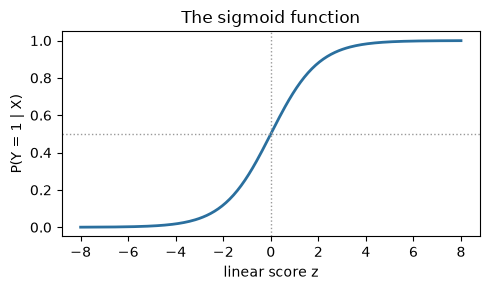

In [3]:
# A small, clean sigmoid figure: any real-valued score maps to (0, 1).
def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-z))

z_grid = np.linspace(-8, 8, 200)
fig, ax = plt.subplots(figsize=(5, 3))
ax.plot(z_grid, sigmoid(z_grid), color="#2a6f9e", lw=2)
ax.axhline(0.5, color="0.6", lw=1, ls=":")
ax.axvline(0, color="0.6", lw=1, ls=":")
ax.set_xlabel("linear score z"); ax.set_ylabel("P(Y = 1 | X)")
ax.set_title("The sigmoid function")
plt.tight_layout(); plt.show()


```{admonition} Think first
:class: think-first
If two participants receive autism probabilities of 0.48 and 0.52, must
their underlying model evidence be very different merely because their
predicted labels differ?
```

```{dropdown} Check your reasoning
No. At the default 0.50 threshold, 0.48 predicts control and 0.52 predicts
autism -- opposite labels -- but the two probabilities themselves are nearly
identical. The sigmoid is continuous: a tiny change in the linear score
crossing the threshold flips the label while barely changing the model's
actual evidence. A predicted label is a summary of a probability, and near a
threshold that summary can be almost arbitrary.
```

## 3. One honest logistic-regression model

**Target:** diagnosis (`group`, recoded autism=1 / control=0). **Positive
class:** autism. **Negative class:** control. **Predictors:** the exact same
360 bilateral cortical-thickness (`fsCT`) columns used throughout Exercises
2-3 -- no diagnosis-derived field, participant id, age, sex, site, or
behavioural score is a predictor. **Split:** a participant-level, stratified
75/25 train/test split, `random_state=42` -- the project's standard
deterministic seed, chosen before this split was ever scored. **Model:**
`StandardScaler` (fit on training rows only) then `LogisticRegression` with
a fixed, ordinary `C=1.0` and a sufficient `max_iter` -- not tuned on the
test set.


In [4]:
# The full set of 360 cortical-thickness columns -- identical recipe and
# code to Exercises 2-3's Section 2.
FEATURES = [c for c in BRAIN_COLS if c.startswith("fsCT_")]
assert all(c.startswith("fsCT_") for c in FEATURES)           # brain-only
assert "group" not in FEATURES                                # no target leakage
print(f"{len(FEATURES)} features, e.g. {FEATURES[:3]}")


360 features, e.g. ['fsCT_L_V1_ROI', 'fsCT_L_MST_ROI', 'fsCT_L_V6_ROI']


In [5]:
# Brain-only X and binary target y. group has no missing values (checked
# above), so every one of the 1004 participants is usable here -- unlike
# Exercise 2's FIQ target, this notebook needs no row filtering.
X = model_df[FEATURES].to_numpy(float)
y = (model_df["group"] == 1).astype(int).to_numpy()   # 1 = autism, 0 = control

# One fixed, reproducible, participant-level split, stratified by y itself
# (the diagnosis label) -- not by a covariate, since y IS diagnosis here.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)
print(f"n_train = {len(y_train)}   n_test = {len(y_test)}   n_features = {X.shape[1]}")
print(f"train autism rate = {y_train.mean():.3f}   test autism rate = {y_test.mean():.3f}")


n_train = 753   n_test = 251   n_features = 360
train autism rate = 0.461   test autism rate = 0.462


In [6]:
# Explicit scaling, written out: fit_transform LEARNS the training columns'
# means/standard deviations; transform then applies those SAME already-
# learned values to the test data -- the scaler is never fitted on the test
# set, exactly like Exercise 2's Section 2.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

explicit_model = LogisticRegression(C=1.0, max_iter=5000)
explicit_model.fit(X_train_scaled, y_train)


,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",5000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

As in Exercise 2, `scikit-learn`'s `make_pipeline` bundles the scaler and the
classifier into one object so `.fit()` always scales before fitting and
`.predict()` / `.predict_proba()` always reuse the scaler already learned
from training data. This is the model used for the rest of this notebook.


In [7]:
# The pipeline shortcut: same two steps, bundled. This is the model used for
# the rest of this notebook.
model = make_pipeline(StandardScaler(), LogisticRegression(C=1.0, max_iter=5000))
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, list(model.classes_).index(1)]
assert np.array_equal(y_pred, explicit_model.predict(X_test_scaled))   # identical to the explicit version above
print("predicted labels and probabilities computed for the held-out test set.")
print("Every metric below uses only these 251 test participants -- none of them were used to fit the model.")


predicted labels and probabilities computed for the held-out test set.
Every metric below uses only these 251 test participants -- none of them were used to fit the model.


## 4. Classification outcomes and metrics

A confusion matrix counts every combination of actual and predicted
diagnosis on the held-out test set. Rows are the **actual** diagnosis,
columns are the **predicted** diagnosis, and autism is the positive class:

| Outcome | Interpretation |
|---|---|
| True negative | A control participant is classified as control. |
| False positive | A control participant is classified as autistic. |
| False negative | An autistic participant is classified as control. |
| True positive | An autistic participant is classified as autistic. |

**Accuracy** is the proportion of all test participants classified
correctly:

$$\mathrm{Accuracy}=\frac{TP+TN}{TP+TN+FP+FN}$$

Two more specific rates matter as much as accuracy, especially under class
imbalance (Section 6):

- **Sensitivity** (recall): the proportion of *actually autistic*
  participants the model detects, $TP/(TP+FN)$;
- **Specificity**: the proportion of *actually control* participants the
  model correctly identifies, $TN/(TN+FP)$.

A single threshold gives one confusion matrix. The **ROC curve** plots
sensitivity against the false-positive rate ($1-\mathrm{specificity}$) as
the threshold sweeps across every possible value, and **AUC** (area under
that curve) summarizes ranking performance independent of any one threshold:
0.5 is chance-level ranking, 1.0 is perfect ranking.


In [8]:
# The honest test-set confusion matrix, accuracy, sensitivity, specificity,
# ROC curve, and AUC -- every number below uses only the 251 test
# participants excluded from fitting.
cm = confusion_matrix(y_test, y_pred, labels=[0, 1])
tn, fp, fn, tp = cm[0, 0], cm[0, 1], cm[1, 0], cm[1, 1]
accuracy = accuracy_score(y_test, y_pred)
sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)
auc = roc_auc_score(y_test, y_proba)

cm_table = pd.DataFrame(
    cm, index=["actual control", "actual autism"], columns=["predicted control", "predicted autism"]
)
display(cm_table)
print(f"accuracy    = {accuracy:.3f}")
print(f"sensitivity = {sensitivity:.3f}  (proportion of autistic participants detected)")
print(f"specificity = {specificity:.3f}  (proportion of control participants correctly identified)")
print(f"AUC         = {auc:.3f}  (0.5 = chance-level ranking, 1.0 = perfect ranking)")


,predicted control,predicted autism
actual control,75,60
actual autism,54,62


accuracy    = 0.546
sensitivity = 0.534  (proportion of autistic participants detected)
specificity = 0.556  (proportion of control participants correctly identified)
AUC         = 0.569  (0.5 = chance-level ranking, 1.0 = perfect ranking)


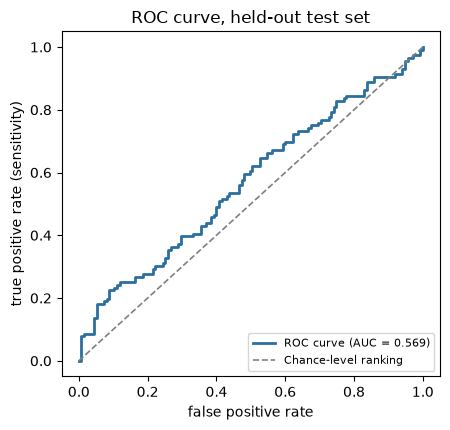

In [9]:
# ROC curve.
fpr, tpr, _ = roc_curve(y_test, y_proba)
fig, ax = plt.subplots(figsize=(4.6, 4.4))
ax.plot(fpr, tpr, color="#2a6f9e", lw=2, label=f"ROC curve (AUC = {auc:.3f})")
ax.plot([0, 1], [0, 1], "--", color="0.5", lw=1.2, label="Chance-level ranking")
ax.set_xlabel("false positive rate"); ax.set_ylabel("true positive rate (sensitivity)")
ax.set_title("ROC curve, held-out test set")
ax.legend(loc="lower right", fontsize=8)
plt.tight_layout(); plt.show()


This discrimination is modest, not strong -- reported honestly rather than
dressed up. This split estimates generalisation to **new participants drawn
from these same 17 ABIDE-II sites**; it is not evidence of generalisation to
a completely unseen acquisition site.

```{admonition} Think first
:class: think-first
Why is `predict_proba()`, not `predict()`, needed to compute the ROC curve
and AUC?
```

```{dropdown} Check your reasoning
`predict()` only returns the class label already decided at one fixed
threshold (0.50 by default) -- a single point, not a curve. The ROC curve
needs the underlying probability for every participant so the threshold can
be swept across every possible value and a new confusion matrix computed at
each one. `predict_proba()` is what makes that sweep possible; `predict()`
alone would only ever give one (FPR, TPR) point.
```

## 5. Interactive activity: choosing a decision threshold

The activity below uses the **exact same fixed test-set predicted
probabilities** computed in Section 3 -- moving the threshold never refits
the model. It recomputes, live, the confusion matrix, accuracy, sensitivity,
specificity, the percentage of participants predicted autistic, and where
the chosen threshold lands on the ROC curve.


<iframe
  title="Interactive decision-threshold exploration for classifying autism vs. control from brain structure"
  src="../../_static/widgets/app/index.html?config=../configs/classification_threshold.json"
  loading="lazy"
  width="100%"
  height="1150"
  class="ml-activity"
  style="width: 100%;"
></iframe>


```{admonition} Think first
:class: think-first
If failing to identify an autistic participant were considered more costly
than falsely flagging a control, would you generally lower or raise the
decision threshold?
```

```{dropdown} Check your reasoning
Lower it. A lower threshold predicts autism more readily -- for a fixed set
of probabilities, lowering the threshold can only increase or hold constant
the number of participants predicted autistic. That increases sensitivity
(fewer autistic participants missed, fewer false negatives) at the cost of
specificity (more controls falsely flagged, more false positives). Whether
that tradeoff is worth it depends on which error is more costly in context
-- the model and its probabilities do not change, only which errors you are
choosing to accept.
```

In [10]:
# Ordinary, editable Python: change threshold and rerun to explore the same
# tradeoff the browser activity shows, using the exact same fixed test-set
# probabilities computed in Section 3 -- the model is never refit here.
threshold = 0.50

thr_pred = (y_proba >= threshold).astype(int)
thr_cm = confusion_matrix(y_test, thr_pred, labels=[0, 1])
thr_tn, thr_fp, thr_fn, thr_tp = thr_cm[0, 0], thr_cm[0, 1], thr_cm[1, 0], thr_cm[1, 1]
thr_accuracy = accuracy_score(y_test, thr_pred)
thr_sensitivity = thr_tp / (thr_tp + thr_fn) if (thr_tp + thr_fn) else float("nan")
thr_specificity = thr_tn / (thr_tn + thr_fp) if (thr_tn + thr_fp) else float("nan")
pct_predicted_autism = 100 * thr_pred.mean()

print(f"threshold = {threshold:.2f}")
print(f"accuracy = {thr_accuracy:.3f}  sensitivity = {thr_sensitivity:.3f}  specificity = {thr_specificity:.3f}")
print(f"predicted autism = {pct_predicted_autism:.1f}%")
print(f"AUC is unchanged by the threshold: {auc:.3f}")


threshold = 0.50
accuracy = 0.546  sensitivity = 0.534  specificity = 0.556
predicted autism = 48.6%
AUC is unchanged by the threshold: 0.569


## 6. Interactive activity: class imbalance and stratified splitting

So far this notebook's cohort (463 autism, 541 control) is only mildly
imbalanced. Real diagnostic cohorts are often far more skewed. The activity
below resamples real ABIDE participants -- control always the majority class
-- into six class ratios (50:50 through 95:5) from a fixed total cohort of
400 participants, and compares a **stratified split**
(`train_test_split(..., stratify=y)`) with an **unstratified split** (no
`stratify`) at each ratio, across five predetermined split seeds. (Neither
side is called a "stratified model" -- stratification is a property of the
*split*, not of what the classifier learns.)

400 was chosen so that even the sparsest ratio, 95:5, stays meaningfully
sparse (20 autism participants total) while a stratified 25% test partition
still keeps a handful of autism participants (about 5) -- few enough to make
the imbalance concrete, without making a stratified test partition
impossible.


<iframe
  title="Interactive class-imbalance and stratified-splitting exploration for classifying autism vs. control from brain structure"
  src="../../_static/widgets/app/index.html?config=../configs/classification_imbalance.json"
  loading="lazy"
  width="100%"
  height="1500"
  class="ml-activity"
  style="width: 100%;"
></iframe>


Stratification preserves the resampled cohort's class proportions across the
split and makes evaluation more reliable; it does not create new minority
observations, does not guarantee good sensitivity, and does not change what
the model's fitting objective optimizes for. Because each split is one
stochastic draw, read differences between the five seeds as examples of
split-to-split stability -- not proof that a stratified split must always
score higher than an unstratified one.

```{admonition} Think first
:class: think-first
At a 95:5 class balance, what accuracy would a classifier achieve by
predicting "control" for everyone? What important information would that
accuracy conceal?
```

```{dropdown} Check your reasoning
95%. At a 95:5 ratio, predicting the majority class (control) for every
participant is correct 95% of the time by construction -- without the model
having learned anything about autism at all. That accuracy conceals the
classifier's sensitivity: it would detect zero of the autistic participants,
even though its headline accuracy sounds excellent. This is exactly why
Section 4 introduced sensitivity and specificity alongside accuracy.
```

In [11]:
# Ordinary, editable Python: change class_ratio and random_state and rerun
# to explore the same imbalance/stratification comparison the browser
# activity shows, using real resampled participants and this notebook's own
# model spec (StandardScaler + LogisticRegression(C=1.0)).
class_ratio = (0.95, 0.05)   # (majority/control, minority/autism)
random_state = 0
cohort_size = 400

rng = np.random.default_rng(20000)  # fixed cohort draw, independent of random_state
majority_idx = np.flatnonzero(y == 0)
minority_idx = np.flatnonzero(y == 1)
n_majority = round(cohort_size * class_ratio[0])
n_minority = cohort_size - n_majority
chosen = np.concatenate([
    rng.choice(majority_idx, size=n_majority, replace=False),
    rng.choice(minority_idx, size=n_minority, replace=False),
])
X_cohort, y_cohort = X[chosen], y[chosen]
print(f"cohort: {len(y_cohort)} participants ({n_majority} control, {n_minority} autism)")

def fit_and_eval(X_c, y_c, stratify):
    Xtr, Xte, ytr, yte = train_test_split(
        X_c, y_c, test_size=0.25, random_state=random_state,
        stratify=y_c if stratify else None,
    )
    m = make_pipeline(StandardScaler(), LogisticRegression(C=1.0, max_iter=5000)).fit(Xtr, ytr)
    pred = m.predict(Xte)
    acc = accuracy_score(yte, pred)
    n_test_pos = int(yte.sum())
    n_test_neg = len(yte) - n_test_pos
    if n_test_pos == 0 or n_test_neg == 0:
        auc_c = "undefined: both classes are required"
    else:
        proba = m.predict_proba(Xte)[:, list(m.classes_).index(1)]
        auc_c = f"{roc_auc_score(yte, proba):.3f}"
    baseline = max(n_test_pos, n_test_neg) / len(yte)
    return ytr, yte, acc, auc_c, baseline

for stratify in (True, False):
    ytr, yte, acc, auc_c, baseline = fit_and_eval(X_cohort, y_cohort, stratify)
    label = "stratified" if stratify else "unstratified"
    print(f"{label:12s}: n_train={len(ytr)} (autism={int(ytr.sum())})  "
          f"n_test={len(yte)} (autism={int(yte.sum())})  "
          f"accuracy={acc:.3f}  AUC={auc_c}  majority baseline={baseline:.3f}")


cohort: 400 participants (380 control, 20 autism)
stratified  : n_train=300 (autism=15)  n_test=100 (autism=5)  accuracy=0.950  AUC=0.267  majority baseline=0.950
unstratified: n_train=300 (autism=16)  n_test=100 (autism=4)  accuracy=0.950  AUC=0.344  majority baseline=0.960


## In summary

- Logistic regression outputs probabilities before class labels; a decision
  threshold turns a probability into a prediction.
- Honest evaluation uses participants excluded from fitting -- every metric
  in this notebook came from the held-out test set.
- A confusion matrix identifies the kinds of correct and incorrect
  decisions a classifier makes.
- Accuracy can be misleading under class imbalance: a classifier that
  predicts only the majority class can score a high accuracy while
  detecting none of the minority class.
- ROC/AUC evaluates ranking across every possible threshold at once; a
  chosen threshold changes the confusion matrix, never the AUC.
- Stratification protects class composition across a train/test split; it
  does not eliminate imbalance or guarantee good performance on the
  minority class.


### Questions to take away

**1.** Why can 95% accuracy describe a useless classifier?

```{dropdown} Answer
At a severe enough class imbalance (e.g. 95:5), predicting the majority
class for everyone reaches 95% accuracy while detecting none of the
minority class. Accuracy alone cannot distinguish that classifier from one
that has genuinely learned to separate the classes -- sensitivity and
specificity are needed to tell them apart.
```

**2.** What generally happens to false negatives when the decision threshold
is lowered?

```{dropdown} Answer
They generally decrease. A lower threshold predicts the positive class
(autism) more readily, so fewer actually-positive participants are missed
(fewer false negatives) -- at the cost of more false positives, since more
controls are now also predicted positive.
```

**3.** What problem does stratification solve, and what problem does it not
solve?

```{dropdown} Answer
Stratification solves the problem of a train/test split accidentally
over- or under-representing one class relative to the full cohort, which
would make the resulting evaluation less reliable. It does not solve class
imbalance itself: it does not create new minority-class observations,
does not guarantee good sensitivity for the minority class, and does not
change what the model's fitting objective optimizes for.
```
